<a href="https://colab.research.google.com/github/SherjinCruz/Unsupervised-Learning-Case-Study/blob/main/Unsupervised_Learning_Sherjin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importing the Modules

In [465]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Importing the file

In [466]:
file = '/content/drive/MyDrive/DSA/Case Study/Unsupervised Learning Case Study/adult_dataset.csv'

df_adult = pd.read_csv(file)
df.head()

,PC1,PC2,PC3,PC4,PC5,PC6,kmeans_cluster,ac_clusters
0,1.696255,-1.919872,1.633394,-1.375896,1.160520,0.919569,3,7
1,0.128463,-0.096566,0.266780,-1.914490,-1.807883,-1.263116,0,10
2,-0.608226,-0.087148,-0.357409,0.218424,-0.082123,0.653713,2,0
3,0.020730,-0.307491,-1.873218,-0.004031,-0.184026,-0.409040,8,2
4,0.133626,0.213845,1.110874,0.238024,-0.432809,-0.858514,0,10


# Examining the data

In [467]:
# checking the columns
df_adult.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'income'],
      dtype='object')

In [468]:
# checking shape
df_adult.shape

(48842, 15)

In [469]:
# checking info

df_adult.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             46400 non-null  float64
 1   workclass       45480 non-null  object 
 2   fnlwgt          48842 non-null  int64  
 3   education       48842 non-null  object 
 4   education-num   48842 non-null  int64  
 5   marital-status  48842 non-null  object 
 6   occupation      45485 non-null  object 
 7   relationship    48842 non-null  object 
 8   race            48842 non-null  object 
 9   sex             48842 non-null  object 
 10  capital-gain    48842 non-null  int64  
 11  capital-loss    48842 non-null  int64  
 12  hours-per-week  46400 non-null  float64
 13  native-country  46137 non-null  object 
 14  income          48842 non-null  object 
dtypes: float64(2), int64(4), object(9)
memory usage: 5.6+ MB


In [470]:
# checking the duplicated values
df_adult.duplicated().sum()

np.int64(16)

In [471]:
# checking the null values
df_adult.isnull().sum()

,0
age,2442
workclass,3362
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,3357
relationship,0
race,0
sex,0


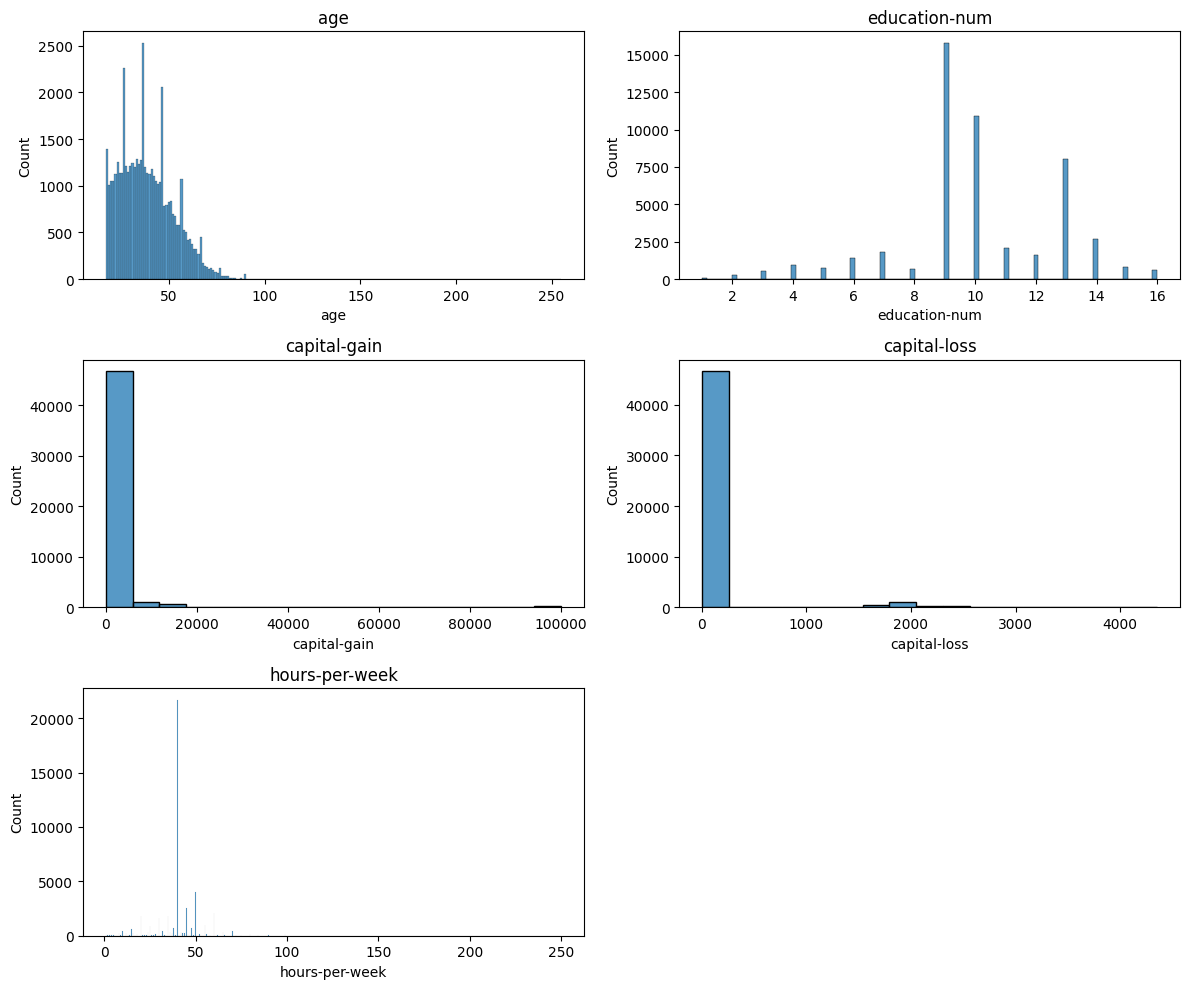

In [472]:
# drawing the histplot for numerical values

num_value_columns = ['age', 'education-num',
       'capital-gain', 'capital-loss', 'hours-per-week']

fig, axes = plt.subplots(3, 2, figsize=(12, 10))
axes = axes.flatten()

for i, col in enumerate(num_value_columns):
    sns.histplot(data=df_adult, x=col, ax=axes[i])
    axes[i].set_title(col)

# Hide any unused subplot axes
for i in range(len(num_value_columns), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

# Data Preprocessing


Removing the duplicated rows

In [473]:
# removing the duplicated rows
df_adult = df_adult.drop_duplicates()

In [474]:
df_adult.shape

(48826, 15)

Dropping the Columns

In [475]:
# Value Count for education
df_adult['education'].value_counts()

,count
education,
HS-grad,15780
Some-college,10874
Bachelors,8021
Masters,2657
Assoc-voc,2060
11th,1812
Assoc-acdm,1601
10th,1389
7th-8th,955


In [476]:
# Value Count for education-num
df_adult['education-num'].value_counts()

,count
education-num,
9,15780
10,10874
13,8021
14,2657
11,2060
7,1812
12,1601
6,1389
4,955


In [477]:
# removing the education columns because education-num coloumn is the encoded version of education column

df_adult = df_adult.drop(columns='education')

# droping fnlwgt (Final Weight): This is an administrative statistical weight representing
# how many people that row represents in the US census. It has no geometric or behavioral meaning
# for grouping individual profiles and will skew distance metrics and income due to its is a target column

df = df_adult.drop(columns=['fnlwgt','income'])

In [478]:
df.columns

Index(['age', 'workclass', 'education-num', 'marital-status', 'occupation',
       'relationship', 'race', 'sex', 'capital-gain', 'capital-loss',
       'hours-per-week', 'native-country'],
      dtype='object')

Checking for ?

In [479]:
# checking weather the ? appears

has_qm_anywhere = (df == "?").sum()

has_qm_anywhere

,0
age,0
workclass,1763
education-num,0
marital-status,0
occupation,1758
relationship,0
race,0
sex,0
capital-gain,0
capital-loss,0


In [480]:
# replacing the ? with nan

df = df.replace('?',np.nan)

In [481]:
has_qm_anywhere = (df == "?").sum()

has_qm_anywhere

,0
age,0
workclass,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0
capital-gain,0
capital-loss,0


Handling the na values

In [482]:
# for age and work hrs per week fill by using median - since it is left skewed

num_col = ['hours-per-week','age']

for col in num_col:
  df[col] = df[col].fillna(df[col].median())

In [483]:
# for workclass,occupation and native contry fill via mode since it is categorical

cat_col = ['workclass','occupation','native-country']

for col in cat_col:
  df[col] = df[col].fillna(df[col].mode()[0])

In [484]:
df.isna().sum()

,0
age,0
workclass,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0
capital-gain,0
capital-loss,0


Checking the Outliers

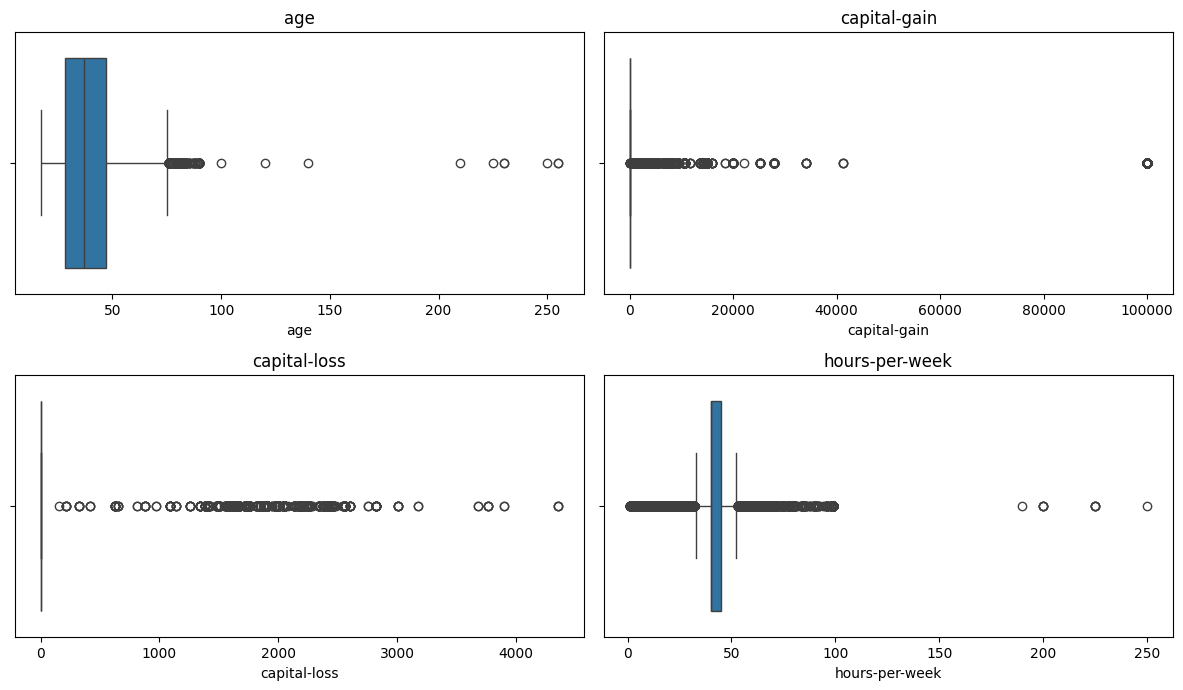

In [485]:
# drawing the boxplot for numerical values

num_value_columns = ['age','capital-gain', 'capital-loss', 'hours-per-week']

fig, axes = plt.subplots(3, 2, figsize=(12, 10))
axes = axes.flatten()

for i, col in enumerate(num_value_columns):
    sns.boxplot(data=df, x=col, ax=axes[i])
    axes[i].set_title(col)

# Hide any unused subplot axes
for i in range(len(num_value_columns), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

In [486]:
# Removing the age which is greater than 100
df = df[df['age'] < 100]

# using the log  transformation for capital gain and capital loss
log_col = ['capital-gain','capital-loss']

for col in log_col:
  df[col] = np.log1p(df[col])

# using winscore methord for hours per week to cap hrs from 10 to 70
df['hours-per-week'] =  df['hours-per-week'].clip(10,70)

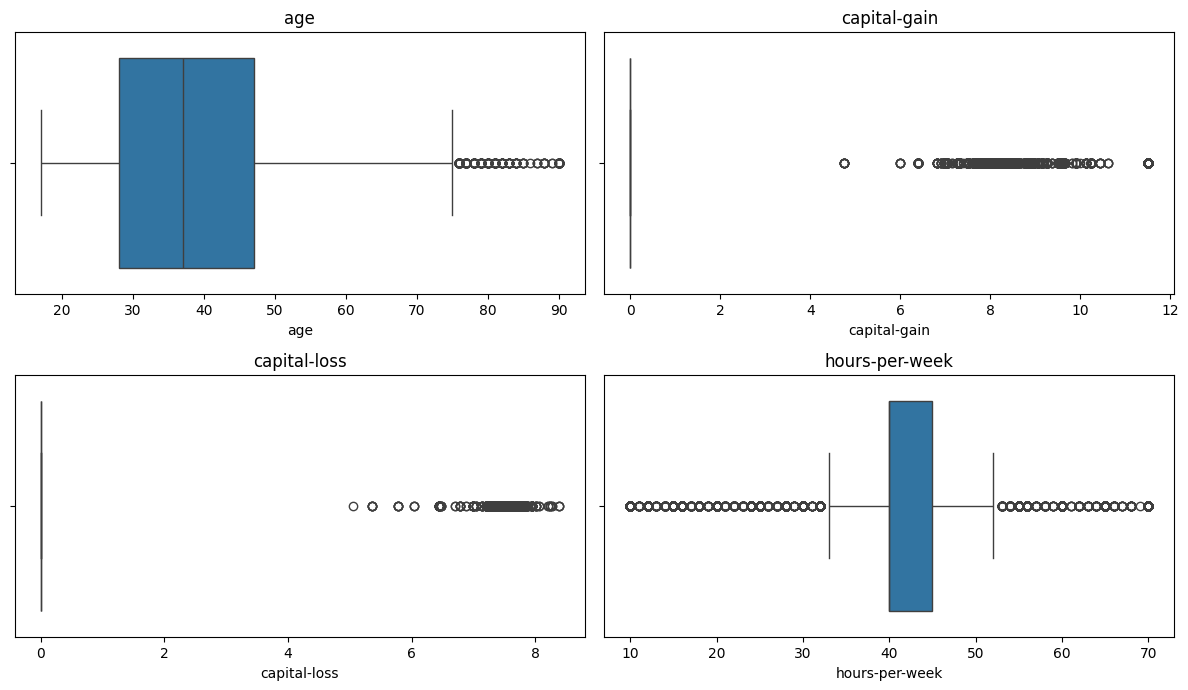

In [487]:
# drawing the boxplot for numerical values

num_value_columns = ['age','capital-gain', 'capital-loss', 'hours-per-week']

fig, axes = plt.subplots(3, 2, figsize=(12, 10))
axes = axes.flatten()

for i, col in enumerate(num_value_columns):
    sns.boxplot(data=df, x=col, ax=axes[i])
    axes[i].set_title(col)

# Hide any unused subplot axes
for i in range(len(num_value_columns), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

# Encoding

In [488]:
cat_col = ['workclass','marital-status',
       'occupation', 'relationship', 'race', 'sex',
       'native-country']

for col in cat_col:
  print('----------------')
  print(df[col].value_counts())

----------------
workclass
Private             37320
Self-emp-not-inc     3649
Local-gov            2973
State-gov            1877
Self-emp-inc         1624
Federal-gov          1346
Without-pay            18
Never-worked            9
Name: count, dtype: int64
----------------
marital-status
Married-civ-spouse       22374
Never-married            16100
Divorced                  6629
Separated                 1530
Widowed                   1518
Married-spouse-absent      628
Married-AF-spouse           37
Name: count, dtype: int64
----------------
occupation
Prof-specialty       10965
Craft-repair          5788
Exec-managerial       5769
Adm-clerical          5327
Sales                 5229
Other-service         4653
Machine-op-inspct     2871
Transport-moving      2238
Handlers-cleaners     1975
Farming-fishing       1428
Tech-support          1382
Protective-serv        943
Priv-house-serv        233
Armed-Forces            15
Name: count, dtype: int64
----------------
relationship
Hu

Encoding Workclass

In [489]:
df['workclass'].value_counts()

,count
workclass,
Private,37320
Self-emp-not-inc,3649
Local-gov,2973
State-gov,1877
Self-emp-inc,1624
Federal-gov,1346
Without-pay,18
Never-worked,9


In [490]:
# combine withoutpay and never worked into one as unemployment/other

combine_other = ['Without-pay','Never-worked']
df['workclass'] = df['workclass'].replace(combine_other,'Unemployed')

# combine various gov job into one
combine_gov = ['Local-gov','Federal-gov','State-gov']
df['workclass'] = df['workclass'].replace(combine_gov,'Gov-jobs')

# combine self job into one
combine_self = ['Self-emp-not-inc','Self-emp-inc']
df['workclass'] = df['workclass'].replace(combine_self,'Gov-jobs')


In [491]:
df['workclass'].value_counts()

,count
workclass,
Private,37320
Gov-jobs,11469
Unemployed,27


In [492]:
# using get dummies alternate to one hot

# Create dummy variables for 'workclass'
workclass_dummies = pd.get_dummies(df['workclass'], prefix='workclass', drop_first=True, dtype=int)

# Concatenate the new dummy variables to the original DataFrame
df = pd.concat([df, workclass_dummies], axis=1)

# Drop the original 'workclass' column as it's now encoded
df = df.drop('workclass', axis=1)

Encoding Martial Status

In [493]:
df['marital-status'].value_counts()

,count
marital-status,
Married-civ-spouse,22374
Never-married,16100
Divorced,6629
Separated,1530
Widowed,1518
Married-spouse-absent,628
Married-AF-spouse,37


In [494]:
# combining all married catagory into one
combine_married = ['Married-civ-spouse','Married-AF-spouse']
df['marital-status'] = df['marital-status'].replace(combine_married,'Married')

# combined single catagory into one
combine_single = ['Widowed','Separated','Married-spouse-absent','Divorced','Never-married']
df['marital-status'] = df['marital-status'].replace(combine_single,'Single')



In [495]:
df['marital-status'].value_counts()

,count
marital-status,
Single,26405
Married,22411


In [496]:
# using get dummies alternate to one hot

# Create dummy variables for 'marital-status'
marital_dummies = pd.get_dummies(df['marital-status'], prefix='marital-status', drop_first=True, dtype=int)

# Concatenate the new dummy variables to the original DataFrame
df = pd.concat([df, marital_dummies], axis=1)

# Drop the original 'marital-status' column as it's now encoded
df = df.drop('marital-status', axis=1)

Encoding Occupation

In [497]:
df['occupation'].value_counts()

,count
occupation,
Prof-specialty,10965
Craft-repair,5788
Exec-managerial,5769
Adm-clerical,5327
Sales,5229
Other-service,4653
Machine-op-inspct,2871
Transport-moving,2238
Handlers-cleaners,1975


In [498]:
# Create a mapping dictionary to group occupations
occupation_map = {
    # White-Collar / Management
    'Prof-specialty': 'White-Collar',
    'Exec-managerial': 'White-Collar',
    'Tech-support': 'White-Collar',
    'Sales': 'White-Collar',
    'Adm-clerical': 'White-Collar',

    # Blue-Collar / Manual Labor
    'Craft-repair': 'Blue-Collar',
    'Machine-op-inspct': 'Blue-Collar',
    'Transport-moving': 'Blue-Collar',
    'Handlers-cleaners': 'Blue-Collar',
    'Farming-fishing': 'Blue-Collar',

    # Service & Security
    'Other-service': 'Service',
    'Protective-serv': 'Service',
    'Priv-house-serv': 'Service',

    # Rare / Military
    'Armed-Forces': 'Other'
}

df['occupation'] = df['occupation'].map(occupation_map)

In [499]:
# using get dummies alternate to one hot

# Create dummy variables for 'occupation'
occupation_dummies = pd.get_dummies(df['occupation'], prefix='occupation', drop_first=True, dtype=int)

# Concatenate the new dummy variables to the original DataFrame
df = pd.concat([df, occupation_dummies], axis=1)

# Drop the original 'occupation' column as it's now encoded
df = df.drop('occupation', axis=1)

Encoding Relationship Columns

In [500]:
df['relationship'].value_counts()

,count
relationship,
Husband,19711
Not-in-family,12567
Own-child,7578
Unmarried,5124
Wife,2331
Other-relative,1505


In [501]:
# Define the mapping dictionary
relationship_map = {
    'Husband': 'Spouse',
    'Wife': 'Spouse',
    'Not-in-family': 'Single_or_Solo',
    'Unmarried': 'Single_or_Solo',
    'Own-child': 'Dependent_or_Other',
    'Other-relative': 'Dependent_or_Other'
}

# Apply mapping
df['relationship'] = df['relationship'].map(relationship_map)

In [502]:
# using get dummies alternate to one hot

# Create dummy variables for 'relationship'
relationship_dummies = pd.get_dummies(df['relationship'], prefix='relationship', drop_first=True, dtype=int)

# Concatenate the new dummy variables to the original DataFrame
df = pd.concat([df, relationship_dummies], axis=1)

# Drop the original 'relationship' column as it's now encoded
df = df.drop('relationship', axis=1)

Encoding Race

In [503]:
# Group rare classes into 'Other'
race_map = {
    'White': 'White',
    'Black': 'Black',
    'Asian-Pac-Islander': 'Other',
    'Amer-Indian-Eskimo': 'Other',
    'Other': 'Other'
}

df['race'] = df['race'].map(race_map)

In [504]:
# using get dummies alternate to one hot

# Create dummy variables for 'race'
race_dummies = pd.get_dummies(df['race'], prefix='race', drop_first=True, dtype=int)

# Concatenate the new dummy variables to the original DataFrame
df = pd.concat([df, race_dummies], axis=1)

# Drop the original 'race' column as it's now encoded
df = df.drop('race', axis=1)

Encoding Sex Columns

In [505]:
# using get dummies alternate to one hot

# Create dummy variables for 'sex'
sex_dummies = pd.get_dummies(df['sex'], prefix='sex', drop_first=True, dtype=int)

# Concatenate the new dummy variables to the original DataFrame
df = pd.concat([df, sex_dummies], axis=1)

# Drop the original 'sex' column as it's now encoded
df = df.drop('sex', axis=1)

Encoding Native Country

In [506]:
def map_country_region(country):
    if country == 'United-States':
        return 'US'
    elif country in ['Mexico', 'Puerto-Rico', 'El-Salvador', 'Cuba', 'Jamaica',
                    'Dominican-Republic', 'Guatemala', 'Columbia', 'Haiti',
                    'Nicaragua', 'Peru', 'Ecuador', 'Trinadad&Tobago', 'Honduras']:
        return 'Latin_America_Caribbean'
    elif country in ['Germany', 'England', 'Italy', 'Poland', 'Portugal',
                    'Greece', 'France', 'Ireland', 'Yugoslavia', 'Scotland',
                    'Hungary', 'Holand-Netherlands']:
        return 'Europe'
    else:
        return 'Asia_Other'

df['native-country'] = df['native-country'].apply(map_country_region)

In [507]:
# using get dummies alternate to one hot

# Create dummy variables for 'native-country'
native_country_dummies = pd.get_dummies(df['native-country'], prefix='native-country', drop_first=True, dtype=int)

# Concatenate the new dummy variables to the original DataFrame
df = pd.concat([df, native_country_dummies], axis=1)

# Drop the original 'native-country' column as it's now encoded
df = df.drop('native-country', axis=1)

In [508]:
df

,age,education-num,capital-gain,capital-loss,hours-per-week,workclass_Private,workclass_Unemployed,marital-status_Single,occupation_Other,occupation_Service,occupation_White-Collar,relationship_Single_or_Solo,relationship_Spouse,race_Other,race_White,sex_Male,native-country_Europe,native-country_Latin_America_Caribbean,native-country_US
0,39.0,13,7.684784,0.0,40.0,0,0,1,0,0,1,1,0,0,1,1,0,0,1
1,50.0,13,0.000000,0.0,13.0,0,0,0,0,0,1,0,1,0,1,1,0,0,1
2,38.0,9,0.000000,0.0,40.0,1,0,1,0,0,0,1,0,0,1,1,0,0,1
3,53.0,7,0.000000,0.0,40.0,1,0,0,0,0,0,0,1,0,0,1,0,0,1
4,28.0,13,0.000000,0.0,40.0,1,0,0,0,0,1,0,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,39.0,13,0.000000,0.0,36.0,1,0,1,0,0,1,1,0,0,1,0,0,0,1
48838,64.0,9,0.000000,0.0,40.0,1,0,1,0,0,1,0,0,0,0,1,0,0,1
48839,38.0,13,0.000000,0.0,50.0,1,0,0,0,0,1,0,1,0,1,1,0,0,1
48840,44.0,13,8.604471,0.0,40.0,1,0,1,0,0,1,0,0,1,0,1,0,0,1


In [509]:
df.columns

Index(['age', 'education-num', 'capital-gain', 'capital-loss',
       'hours-per-week', 'workclass_Private', 'workclass_Unemployed',
       'marital-status_Single', 'occupation_Other', 'occupation_Service',
       'occupation_White-Collar', 'relationship_Single_or_Solo',
       'relationship_Spouse', 'race_Other', 'race_White', 'sex_Male',
       'native-country_Europe', 'native-country_Latin_America_Caribbean',
       'native-country_US'],
      dtype='object')

# Scaling

In [510]:
num_col = ['age',	'education-num','capital-gain','capital-loss','hours-per-week']

# using power transformer methord

from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method='yeo-johnson',standardize = True)
df[num_col] = pt.fit_transform(df[num_col])

In [511]:
df

,age,education-num,capital-gain,capital-loss,hours-per-week,workclass_Private,workclass_Unemployed,marital-status_Single,occupation_Other,occupation_Service,occupation_White-Collar,relationship_Single_or_Solo,relationship_Spouse,race_Other,race_White,sex_Male,native-country_Europe,native-country_Latin_America_Caribbean,native-country_US
0,0.173192,1.167221,3.331373,-0.221398,-0.054161,0,0,1,0,0,1,1,0,0,1,1,0,0,1
1,0.905759,1.167221,-0.300175,-0.221398,-2.275708,0,0,0,0,0,1,0,1,0,1,1,0,0,1
2,0.098521,-0.464361,-0.300175,-0.221398,-0.054161,1,0,1,0,0,0,1,0,0,1,1,0,0,1
3,1.082409,-1.200532,-0.300175,-0.221398,-0.054161,1,0,0,0,0,0,0,1,0,0,1,0,0,1
4,-0.752532,1.167221,-0.300175,-0.221398,-0.054161,1,0,0,0,0,1,0,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,0.173192,1.167221,-0.300175,-0.221398,-0.411275,1,0,1,0,0,1,1,0,0,1,0,0,0,1
48838,1.666974,-0.464361,-0.300175,-0.221398,-0.054161,1,0,1,0,0,1,0,0,0,0,1,0,0,1
48839,0.098521,1.167221,-0.300175,-0.221398,0.870371,1,0,0,0,0,1,0,1,0,1,1,0,0,1
48840,0.524692,1.167221,3.331389,-0.221398,-0.054161,1,0,1,0,0,1,0,0,1,0,1,0,0,1


In [512]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48816 entries, 0 to 48841
Data columns (total 19 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   age                                     48816 non-null  float64
 1   education-num                           48816 non-null  float64
 2   capital-gain                            48816 non-null  float64
 3   capital-loss                            48816 non-null  float64
 4   hours-per-week                          48816 non-null  float64
 5   workclass_Private                       48816 non-null  int64  
 6   workclass_Unemployed                    48816 non-null  int64  
 7   marital-status_Single                   48816 non-null  int64  
 8   occupation_Other                        48816 non-null  int64  
 9   occupation_Service                      48816 non-null  int64  
 10  occupation_White-Collar                 48816 non-null  int64  

# Exploratory Analysis

Visualize Feature Distributions

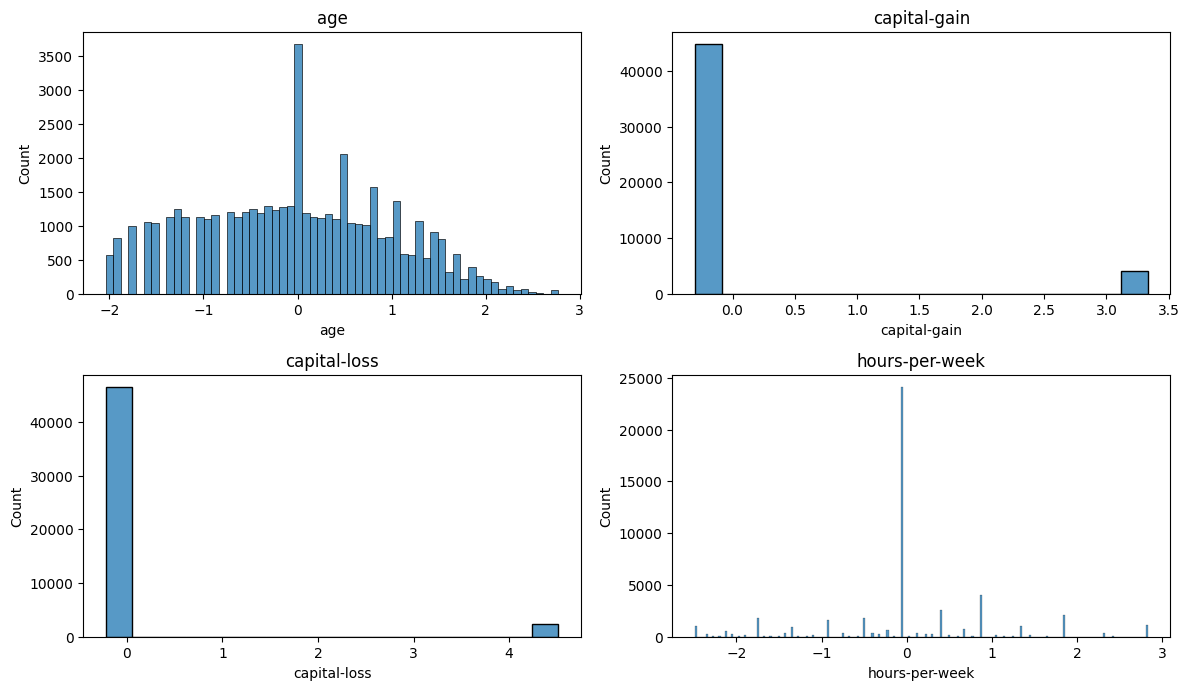

In [513]:
# for continous numerical column using hist plot

# drawing the histplot for numerical values

num_value_columns = ['age','capital-gain', 'capital-loss', 'hours-per-week']

fig, axes = plt.subplots(3, 2, figsize=(12, 10))
axes = axes.flatten()

for i, col in enumerate(num_value_columns):
    sns.histplot(data=df, x=col, ax=axes[i])
    axes[i].set_title(col)

# Hide any unused subplot axes
for i in range(len(num_value_columns), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

Analysing Corellation between the Variables

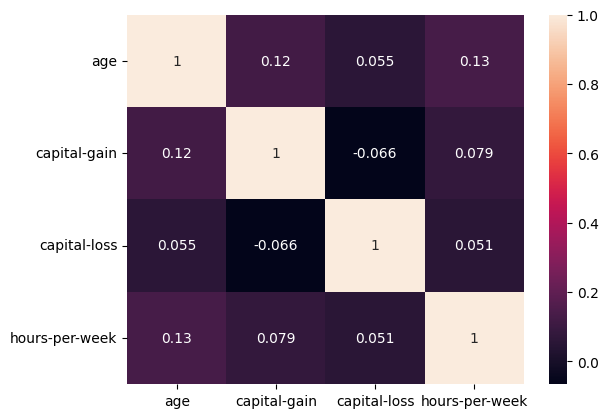

In [514]:
# using the heat map

num_value_columns = ['age','capital-gain', 'capital-loss', 'hours-per-week']
corr_matrix = df[num_value_columns].corr()
sns.heatmap(corr_matrix,annot=True)
plt.show()

Dimensionality Reduction using pca

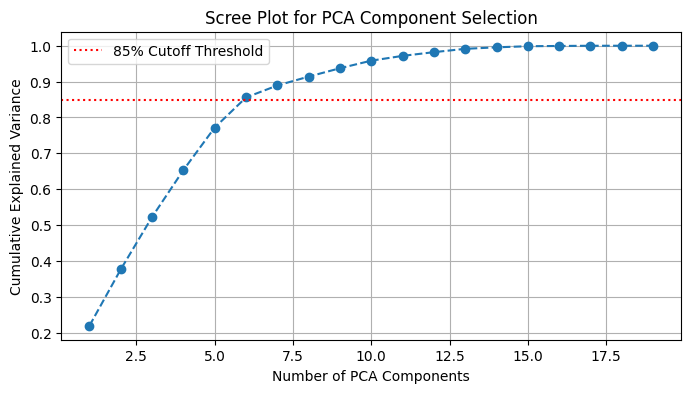

In [515]:
# Checking how many components is needed using graph

from sklearn.decomposition import PCA

# Fit PCA on all components
pca_full = PCA().fit(df)
cum_variance = np.cumsum(pca_full.explained_variance_ratio_)

# Plot Cumulative Explained Variance
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(cum_variance) + 1), cum_variance, marker='o', linestyle='--')
plt.axhline(y=0.85, color='r', linestyle=':', label='85% Cutoff Threshold')
plt.xlabel('Number of PCA Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Scree Plot for PCA Component Selection')
plt.grid(True)
plt.legend()
plt.show()

In [516]:
# Transforming the data with pca

from sklearn.decomposition import PCA

pca = PCA(n_components = 0.85,random_state = 42)
df = pca.fit_transform(df)

print(f"Dataset reduced to {df.shape[1]} principal components.")

Dataset reduced to 6 principal components.


In [517]:
# Generate column names based on the number of components
pca_cols = [f'PC{i+1}' for i in range(df.shape[1])]

# Convert NumPy array to DataFrame
df = pd.DataFrame(data=df, columns=pca_cols)

# Display the first few rows
print(df.head())

        PC1       PC2       PC3       PC4       PC5       PC6
0  1.696255 -1.919872  1.633394 -1.375896  1.160520  0.919569
1  0.128463 -0.096566  0.266780 -1.914490 -1.807883 -1.263116
2 -0.608226 -0.087148 -0.357409  0.218424 -0.082123  0.653713
3  0.020730 -0.307491 -1.873218 -0.004031 -0.184026 -0.409040
4  0.133626  0.213845  1.110874  0.238024 -0.432809 -0.858514


In [518]:
# reducing the row upto 2000
df = df[:2000]

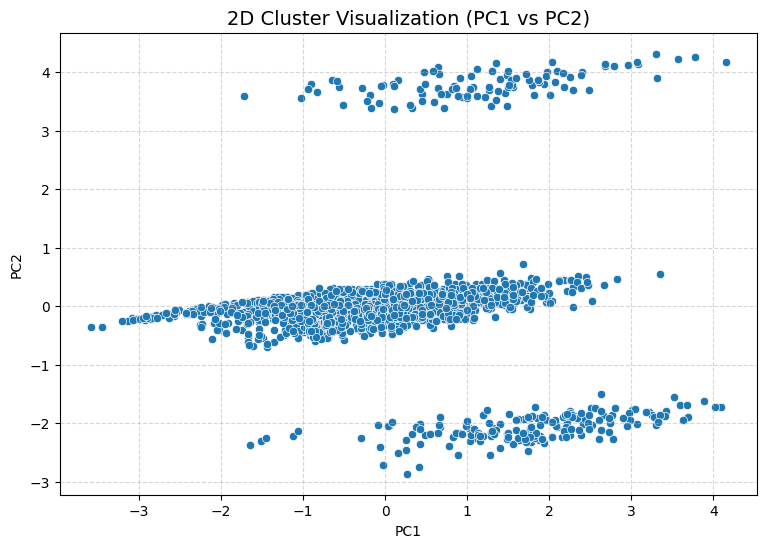

In [519]:
# Plot PC1 against PC2

plt.figure(figsize=(9, 6))

sns.scatterplot(x='PC1', y='PC2', data=df)

plt.title('2D Cluster Visualization (PC1 vs PC2)', fontsize=14)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Clustering

KMeans Clustering

In [520]:
df_kmeans = df

In [521]:
# importing the kmeans
from sklearn.cluster import KMeans

wcss = []

for i in range(1,16):
  km_obj = KMeans(n_clusters=i,init='k-means++',
                  max_iter=300,n_init=10,random_state=0)
  km_obj.fit(df_kmeans)
  wcss.append(km_obj.inertia_)

In [522]:
# importing silhouette_score
from sklearn.metrics import silhouette_score

for i in range(2,16):
  print(f'{i} clusters - {silhouette_score(df_kmeans,km_obj.labels_)}')

2 clusters - 0.2819437958741936
3 clusters - 0.2819437958741936
4 clusters - 0.2819437958741936
5 clusters - 0.2819437958741936
6 clusters - 0.2819437958741936
7 clusters - 0.2819437958741936
8 clusters - 0.2819437958741936
9 clusters - 0.2819437958741936
10 clusters - 0.2819437958741936
11 clusters - 0.2819437958741936
12 clusters - 0.2819437958741936
13 clusters - 0.2819437958741936
14 clusters - 0.2819437958741936
15 clusters - 0.2819437958741936


In [523]:
wcss

[11610.52814521511,
 9394.873722098608,
 7238.891067454719,
 5816.078589464695,
 4903.917845411065,
 4305.322017239104,
 3901.8843115039786,
 3589.2979382218905,
 3312.0016267779083,
 3103.745295703698,
 2952.66301456387,
 2749.563027731046,
 2643.023789605438,
 2501.598467215811,
 2439.088111368895]

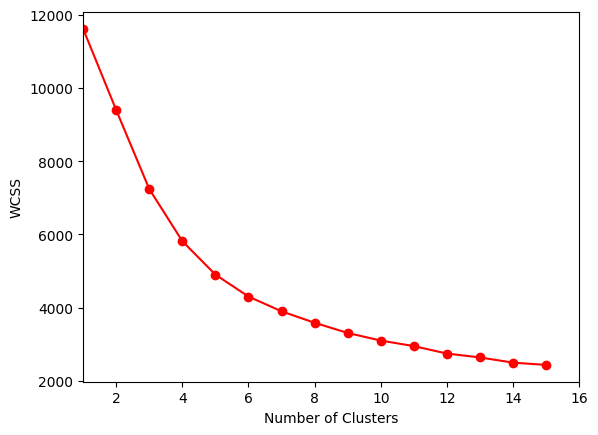

In [524]:
# elbow curve

plt.plot(range(1,16),wcss,c='red',marker='o')
plt.xlabel('Number of Clusters')
plt.xlim(1,16)
plt.ylabel('WCSS')
plt.show()

In [525]:
# getting the k value using the elbow curve
km_obj1 = KMeans(n_clusters=11,init='k-means++',
                 max_iter=300,n_init=10,random_state=0)
km_obj1.fit(df_kmeans)

kmeans_cluster_labels = km_obj1.labels_
kmeans_cluster_labels

array([3, 0, 2, ..., 0, 2, 9], dtype=int32)

In [526]:
df_kmeans['kmeans_cluster'] = kmeans_cluster_labels
df_kmeans.head()

,PC1,PC2,PC3,PC4,PC5,PC6,kmeans_cluster
0,1.696255,-1.919872,1.633394,-1.375896,1.160520,0.919569,3
1,0.128463,-0.096566,0.266780,-1.914490,-1.807883,-1.263116,0
2,-0.608226,-0.087148,-0.357409,0.218424,-0.082123,0.653713,2
3,0.020730,-0.307491,-1.873218,-0.004031,-0.184026,-0.409040,8
4,0.133626,0.213845,1.110874,0.238024,-0.432809,-0.858514,0


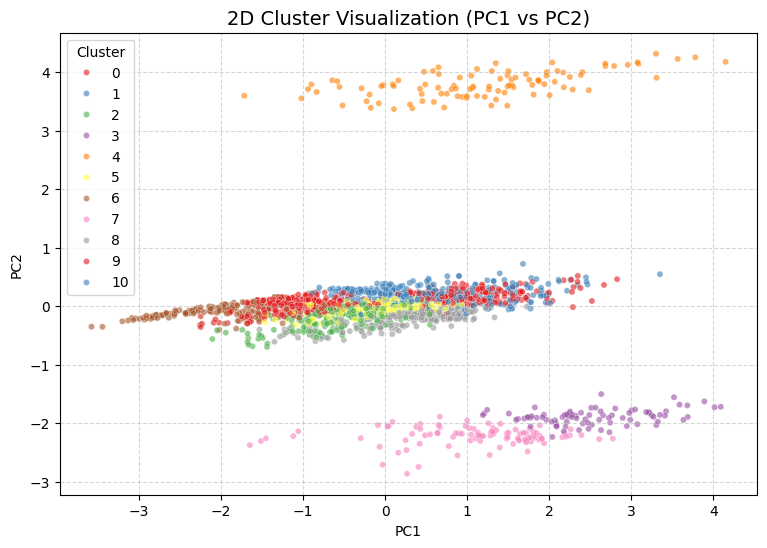

In [527]:
plt.figure(figsize=(9, 6))

# Plot PC1 against PC2 color-coded by predicted cluster labels
sns.scatterplot(x='PC1', y='PC2', hue='kmeans_cluster', data=df_kmeans,
                palette='Set1', alpha=0.6, s=20
)

plt.title('2D Cluster Visualization (PC1 vs PC2)', fontsize=14)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='Cluster')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [528]:
from sklearn.metrics import silhouette_score
silhouette_score(df_kmeans,kmeans_cluster_labels)

np.float64(0.5050329162085877)

Agglometric Clustering

In [529]:
# reducing the row upto 2000
df_ac = df

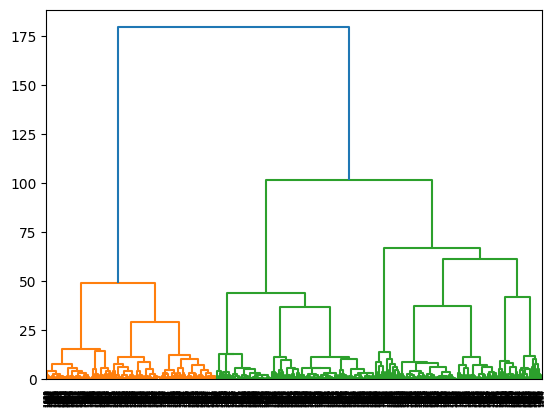

In [530]:
from scipy.cluster.hierarchy import linkage,dendrogram

mergings = linkage(df_ac,method='ward')
dendrogram(mergings)
plt.show()

In [531]:
from sklearn.cluster import AgglomerativeClustering
ac_obj = AgglomerativeClustering(
    n_clusters = 11,
    metric = 'euclidean',
    linkage = 'ward'
)

ac_clusters = ac_obj.fit_predict(df_ac)
ac_clusters

array([ 7, 10,  0, ..., 10,  0,  5])

In [532]:
df_ac['ac_clusters'] = ac_clusters

In [533]:
from sklearn.metrics import silhouette_score
silhouette_score(df_ac,ac_clusters)

np.float64(0.6814932195396196)

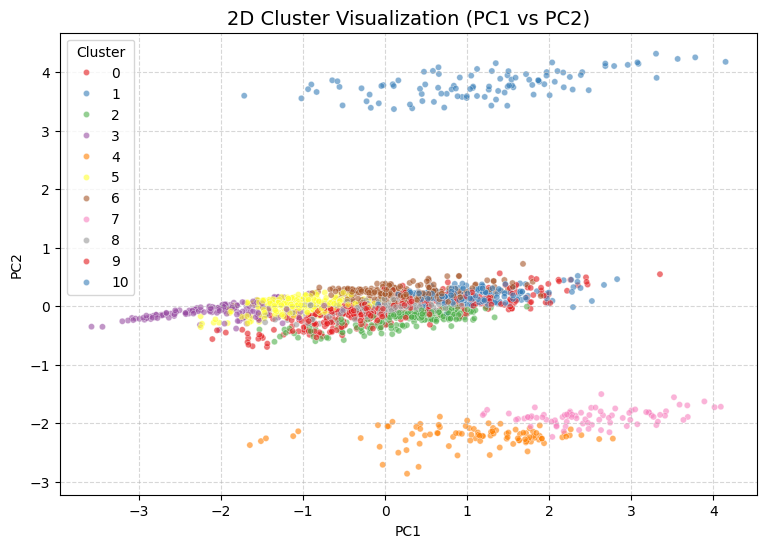

In [534]:
plt.figure(figsize=(9, 6))

# Plot PC1 against PC2 color-coded by predicted cluster labels
sns.scatterplot(x='PC1', y='PC2', hue='ac_clusters', data=df_ac,
                palette='Set1', alpha=0.6, s=20
)

plt.title('2D Cluster Visualization (PC1 vs PC2)', fontsize=14)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='Cluster')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Interpolation and Profiting

In [535]:
df_interpret = df_adult.iloc[:len(df_ac)].copy()
df_interpret['ac_clusters'] = df_ac['ac_clusters']

for cluster in sorted(df_interpret['ac_clusters'].unique()):
    print("\n========== Cluster", cluster, "==========")

    cluster_data = df_interpret[df_interpret['ac_clusters'] == cluster]

    columns = ['age', 'workclass', 'occupation','hours-per-week','native-country']

    for col in columns:
        print("\n", col)
        print(
            cluster_data[col]
            .value_counts(normalize=True)
            .head(3)
            .mul(100)
            .round(1)
        )



========== Cluster 0 ==========

 age
age
43.0    5.1
37.0    4.3
35.0    4.3
Name: proportion, dtype: float64

 workclass
workclass
Private             72.2
Self-emp-not-inc     6.7
Local-gov            6.7
Name: proportion, dtype: float64

 occupation
occupation
Adm-clerical      13.3
Prof-specialty    12.5
Other-service     12.1
Name: proportion, dtype: float64

 hours-per-week
hours-per-week
40.0    45.4
45.0     7.6
50.0     7.6
Name: proportion, dtype: float64

 native-country
native-country
United-States    92.8
?                 1.6
Mexico            1.2
Name: proportion, dtype: float64

========== Cluster 1 ==========

 age
age
23.0    6.2
38.0    5.2
43.0    5.2
Name: proportion, dtype: float64

 workclass
workclass
Private             68.8
Self-emp-not-inc     9.7
?                    8.6
Name: proportion, dtype: float64

 occupation
occupation
Sales             15.3
Craft-repair      13.3
Prof-specialty    11.2
Name: proportion, dtype: float64

 hours-per-week
hours-per-we

In [536]:
for cluster in sorted(df_interpret['ac_clusters'].unique()):
    cluster_data = df_interpret[df_interpret['ac_clusters'] == cluster]

    print(
        "Cluster", cluster,
        "Average age:", round(cluster_data['age'].mean(), 2)
    )

Cluster 0 Average age: 40.06
Cluster 1 Average age: 37.2
Cluster 2 Average age: 39.95
Cluster 3 Average age: 38.66
Cluster 4 Average age: 38.24
Cluster 5 Average age: 37.85
Cluster 6 Average age: 39.04
Cluster 7 Average age: 37.34
Cluster 8 Average age: 39.15
Cluster 9 Average age: 38.37
Cluster 10 Average age: 39.62


Comparing Clusters

In [537]:
pd.crosstab(
    df_ac['ac_clusters'],
    df_adult['income'],
    normalize='index'
).round(3) * 100

income,<=50K,>50K
ac_clusters,,
0,76.5,23.5
1,80.0,20.0
2,76.0,24.0
3,74.4,25.6
4,63.5,36.5
5,77.4,22.6
6,72.6,27.4
7,72.8,27.2
8,76.2,23.8


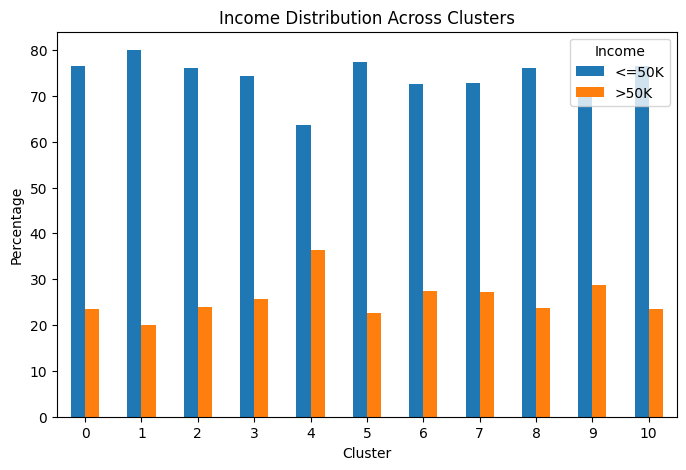

In [538]:
income_cluster = pd.crosstab(
    df_ac['ac_clusters'],
    df_adult['income'],
    normalize='index'
) * 100

income_cluster.plot(
    kind='bar',
    figsize=(8, 5)
)

plt.xlabel("Cluster")
plt.ylabel("Percentage")
plt.title("Income Distribution Across Clusters")
plt.xticks(rotation=0)
plt.legend(title="Income")
plt.show()